# Breast Cancer Diagnostic Analysis — Visualizations

This notebook generates charts from SQL query outputs exported from MySQL Workbench.

**Before running:**
- Run all 5 SQL scripts in MySQL Workbench in numbered order
- Export the following query results as CSV into the `/data/` folder:
  - `class_distribution.csv` — from 01, class distribution query
  - `feature_separation.csv` — from 03, final ranked feature separation table
  - `univariate_stats.csv` — from 02, summary stats by diagnosis
  - `variance_comparison.csv` — from 04, variance by diagnosis
  - `summary_rankings.csv` — from 05, final ranked feature table

Charts are saved to `/visuals/` for embedding in the README.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# Create visuals directory if it doesn't exist
os.makedirs('../visuals', exist_ok=True)

# Color palette — consistent across all charts
COLOR_MALIGNANT = '#C0392B'
COLOR_BENIGN    = '#2471A3'
COLOR_NEUTRAL   = '#717D7E'

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'figure.dpi'       : 150
})

print('Setup complete.')

Setup complete.


## 1. Class Distribution

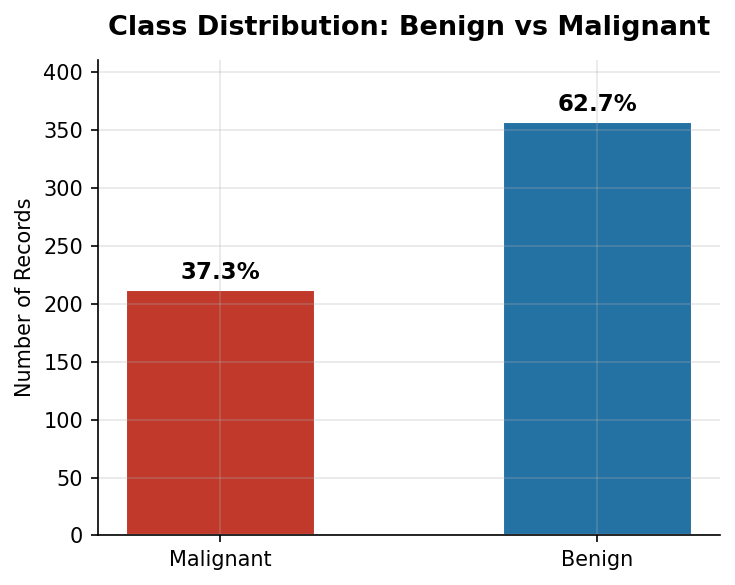

Saved: visuals/class_distribution.png


In [5]:
# Load from MySQL Workbench export
# Expected columns: diagnosis, count, pct_of_total
dist = pd.read_csv('data/class_distribution.csv')

fig, ax = plt.subplots(figsize=(5, 4))

colors = [COLOR_MALIGNANT if d == 'M' else COLOR_BENIGN for d in dist['diagnosis']]
labels = ['Malignant' if d == 'M' else 'Benign' for d in dist['diagnosis']]

bars = ax.bar(labels, dist['count'], color=colors, width=0.5, edgecolor='white')

for bar, pct in zip(bars, dist['pct_of_total']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{pct}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('Class Distribution: Benign vs Malignant', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Number of Records')
ax.set_ylim(0, dist['count'].max() * 1.15)

plt.tight_layout()
plt.savefig('../visuals/class_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: visuals/class_distribution.png')

## 2. Top Features by Malignant-to-Benign Ratio
Key chart — shows which cell measurements separate malignant from benign most clearly.

In [ ]:
# Expected columns: feature, malignant_to_benign_ratio, feature_type
sep = pd.read_csv('../data/summary_rankings.csv')
sep = sep.sort_values('malignant_to_benign_ratio', ascending=True).tail(12)

colors = [COLOR_MALIGNANT if ft == 'worst' else COLOR_NEUTRAL for ft in sep['feature_type']]

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.barh(sep['feature'], sep['malignant_to_benign_ratio'], color=colors, edgecolor='white')

for bar, val in zip(bars, sep['malignant_to_benign_ratio']):
    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}x',
        va='center', fontsize=9
    )

ax.axvline(x=1, color='black', linewidth=0.8, linestyle='--', alpha=0.5, label='No difference (1.0x)')

worst_patch  = mpatches.Patch(color=COLOR_MALIGNANT, label='Worst-case feature')
mean_patch   = mpatches.Patch(color=COLOR_NEUTRAL,   label='Mean feature')
ax.legend(handles=[worst_patch, mean_patch], loc='lower right', fontsize=9)

ax.set_title('Malignant-to-Benign Ratio by Feature\n(Higher = stronger diagnostic signal)', 
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Malignant Mean / Benign Mean')
ax.set_xlim(0, sep['malignant_to_benign_ratio'].max() * 1.15)

plt.tight_layout()
plt.savefig('../visuals/feature_separation_chart.png', bbox_inches='tight')
plt.show()
print('Saved: visuals/feature_separation_chart.png')

## 3. Mean vs Worst Feature: Which Separates Better?
Tests whether worst-case measurements consistently outperform mean measurements as diagnostic signals.

In [ ]:
# Expected columns: measurement, mean_feature_ratio, worst_feature_ratio, worst_advantage
# From the second query in 03_feature_separation.sql
mv = pd.read_csv('../data/mean_vs_worst.csv')
mv = mv.sort_values('worst_advantage', ascending=False)

x       = np.arange(len(mv))
width   = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, mv['mean_feature_ratio'],  width, label='Mean feature',        color=COLOR_NEUTRAL,   alpha=0.85, edgecolor='white')
ax.bar(x + width/2, mv['worst_feature_ratio'], width, label='Worst-case feature',  color=COLOR_MALIGNANT, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(mv['measurement'], fontsize=10)
ax.set_ylabel('Malignant / Benign Ratio')
ax.set_title('Mean vs Worst-Case Features:\nWhich Carries Stronger Diagnostic Signal?',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.axhline(y=1, color='black', linewidth=0.8, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../visuals/mean_vs_worst_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: visuals/mean_vs_worst_comparison.png')

## 4. Distribution Boxplots — Key Features by Diagnosis
Shows spread and overlap between classes for the top diagnostic features.

In [ ]:
# Load raw data directly for boxplots
# This is the only chart that reads from the raw CSV rather than SQL export
df = pd.read_csv('../data/breast_cancer.csv', header=None)

# Assign column names (UCI dataset has no header row)
cols = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean',
    'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se',
    'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se',
    'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst',
    'symmetry_worst', 'fractal_dimension_worst'
]
df.columns = cols

features_to_plot = [
    'concave_points_worst',
    'concavity_worst',
    'radius_worst',
    'area_worst'
]

fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for ax, feature in zip(axes, features_to_plot):
    benign_data    = df[df['diagnosis'] == 'B'][feature]
    malignant_data = df[df['diagnosis'] == 'M'][feature]

    bp = ax.boxplot(
        [benign_data, malignant_data],
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color='white', linewidth=2)
    )

    bp['boxes'][0].set_facecolor(COLOR_BENIGN)
    bp['boxes'][1].set_facecolor(COLOR_MALIGNANT)
    for element in ['whiskers', 'caps', 'fliers']:
        for item in bp[element]:
            item.set_color(COLOR_NEUTRAL)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Benign', 'Malignant'], fontsize=9)
    ax.set_title(feature.replace('_', '\n'), fontsize=9, fontweight='bold')

fig.suptitle('Distribution by Diagnosis — Top Separating Features',
             fontsize=13, fontweight='bold', y=1.02)

benign_patch    = mpatches.Patch(color=COLOR_BENIGN,    label='Benign')
malignant_patch = mpatches.Patch(color=COLOR_MALIGNANT, label='Malignant')
fig.legend(handles=[benign_patch, malignant_patch], loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/distribution_by_diagnosis.png', bbox_inches='tight')
plt.show()
print('Saved: visuals/distribution_by_diagnosis.png')

## 5. Variance Comparison by Diagnosis
Are malignant tumors more morphologically variable than benign ones?

In [ ]:
# Expected columns: diagnosis, var_radius_worst, var_area_worst,
# var_concavity_worst, var_concave_points_worst, var_fractal_dimension_worst, var_symmetry_worst
var_df = pd.read_csv('../data/variance_comparison.csv')

var_cols    = [c for c in var_df.columns if c.startswith('var_')]
labels      = [c.replace('var_', '').replace('_', '\n') for c in var_cols]

benign_vals    = var_df[var_df['diagnosis'] == 'B'][var_cols].values.flatten()
malignant_vals = var_df[var_df['diagnosis'] == 'M'][var_cols].values.flatten()

# Normalize to malignant = 1 for readability (relative variance)
relative = benign_vals / malignant_vals

x     = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x, relative, color=[
    COLOR_BENIGN if r < 1 else COLOR_MALIGNANT for r in relative
], edgecolor='white', alpha=0.85)

ax.axhline(y=1, color='black', linewidth=1, linestyle='--', alpha=0.5, label='Equal variance')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Benign Variance / Malignant Variance')
ax.set_title('Relative Variance: Benign vs Malignant\n(Below 1.0 = malignant is more variable)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/variance_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: visuals/variance_comparison.png')

---
## Summary

Charts saved to `/visuals/`:
- `class_distribution.png`
- `feature_separation_chart.png` ← embed this one in README
- `mean_vs_worst_comparison.png`
- `distribution_by_diagnosis.png` ← embed this one in README
- `variance_comparison.png`

Update the **Key Findings** section in `README.md` with actual numbers from your SQL output before publishing.